In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:
df= pd.read_csv('House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,5/18/2022,2,10000.0,1100.0,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,5/13/2022,2,20000.0,NaN,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
2,5/16/2022,2,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,7/4/2022,2,10000.0,NaN,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,5/9/2022,2,7500.0,850.0,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4746 non-null   object 
 1   BHK                4746 non-null   int64  
 2   Rent               4741 non-null   float64
 3   Size               4738 non-null   float64
 4   Floor              4746 non-null   object 
 5   Area Type          4739 non-null   object 
 6   Area Locality      4746 non-null   object 
 7   City               4746 non-null   object 
 8   Furnishing Status  4746 non-null   object 
 9   Tenant Preferred   4746 non-null   object 
 10  Bathroom           4742 non-null   float64
 11  Point of Contact   4746 non-null   object 
dtypes: float64(3), int64(1), object(8)
memory usage: 445.1+ KB


In [47]:
df.shape

(4746, 12)

In [48]:
df.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.741000e+03,4738.000000,4742.000000
mean,2.083860,3.502340e+04,967.936049,1.965837
std,0.832256,7.814214e+04,634.562635,0.884904
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [49]:
q1 = df['Rent'].quantile(0.25)
q3 = df['Rent'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df['Rent'] >= lower) & (df['Rent'] <= upper)]

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
x=df.drop('Rent',axis=1)
y=df['Rent']

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)  

In [53]:
x_train.isnull().sum().sort_values(ascending=False).head(6)

Size             5
Area Type        3
Bathroom         2
BHK              0
Posted On        0
Area Locality    0
dtype: int64

In [54]:
from sklearn.impute import SimpleImputer
impute=SimpleImputer(strategy="most_frequent")

In [55]:
col=['Area Type','Size','Bathroom']
x_train[col]=impute.fit_transform(x_train[col])
x_test[col]=impute.transform(x_test[col])

In [56]:
x_train.isnull().sum().sum(),x_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [57]:
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_test.mean())

In [58]:
y_train.isnull().sum().sum(),y_test.isnull().sum().sum()

(np.int64(0), np.int64(0))

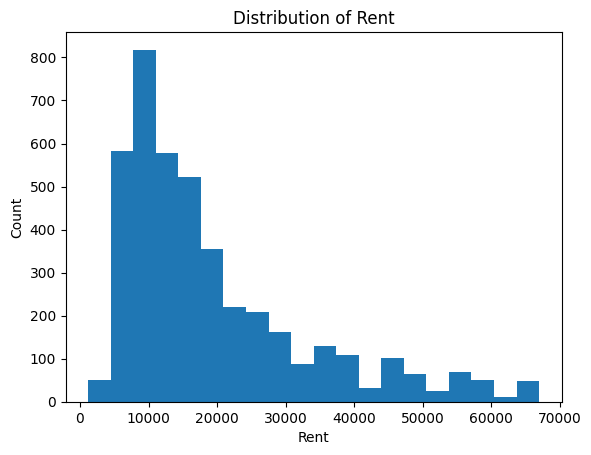

In [59]:
plt.hist(df['Rent'],bins=20)
plt.xlabel('Rent')
plt.ylabel('Count')
plt.title('Distribution of Rent')
plt.show()

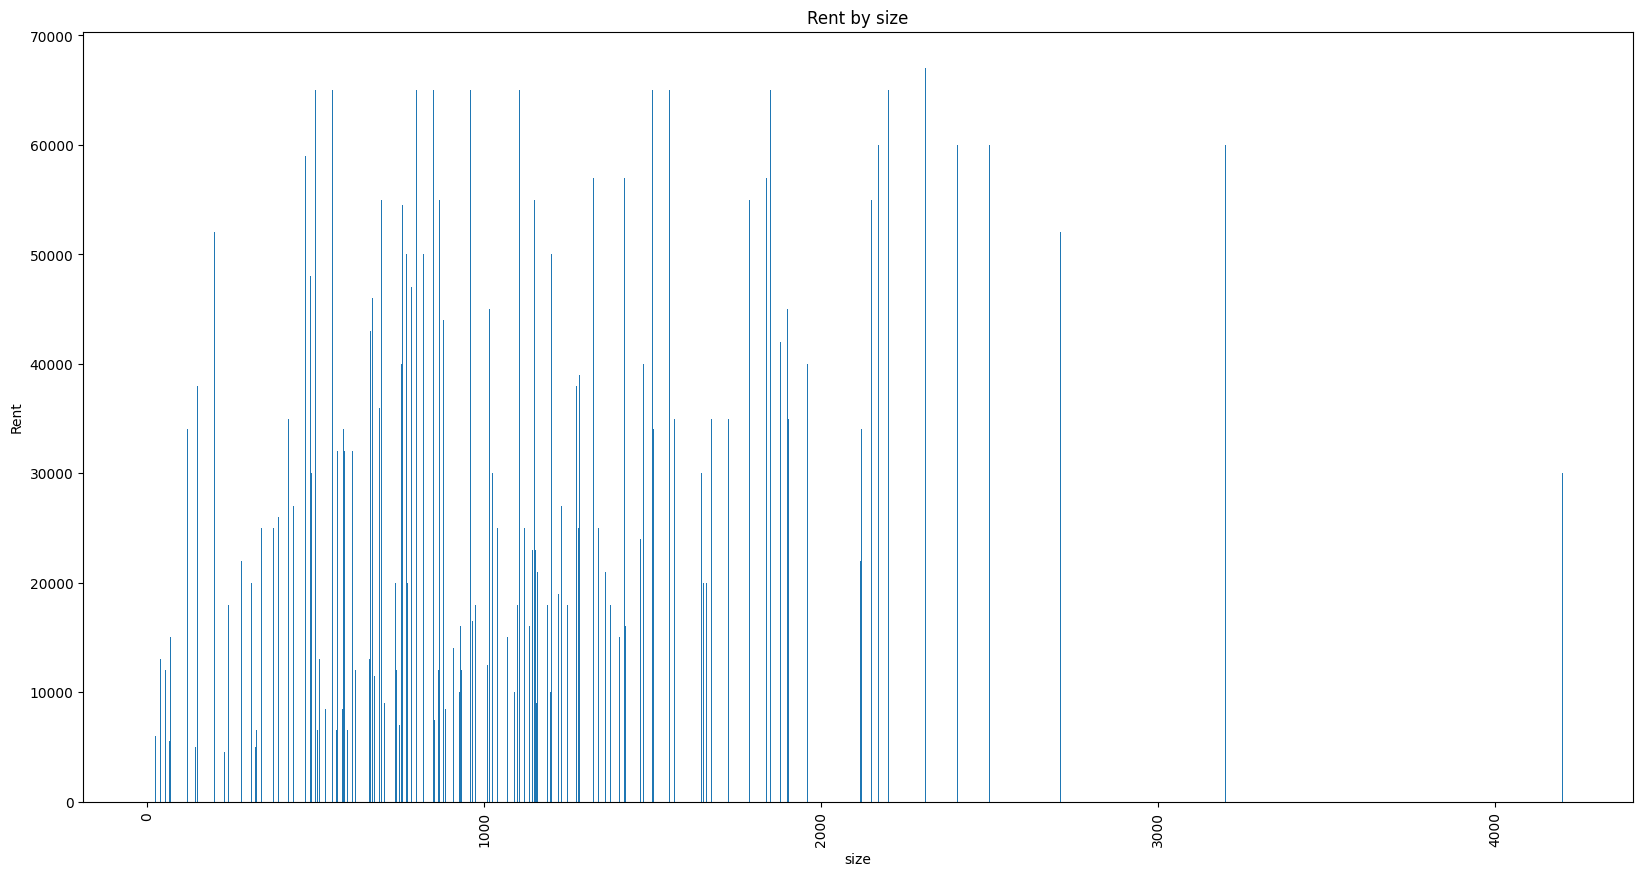

In [60]:
plt.figure(figsize=(20,10))
plt.bar(x_train['Size'],y_train)
plt.xlabel('size')
plt.ylabel('Rent')
plt.title('Rent by size')
plt.xticks(rotation=90)
plt.show()


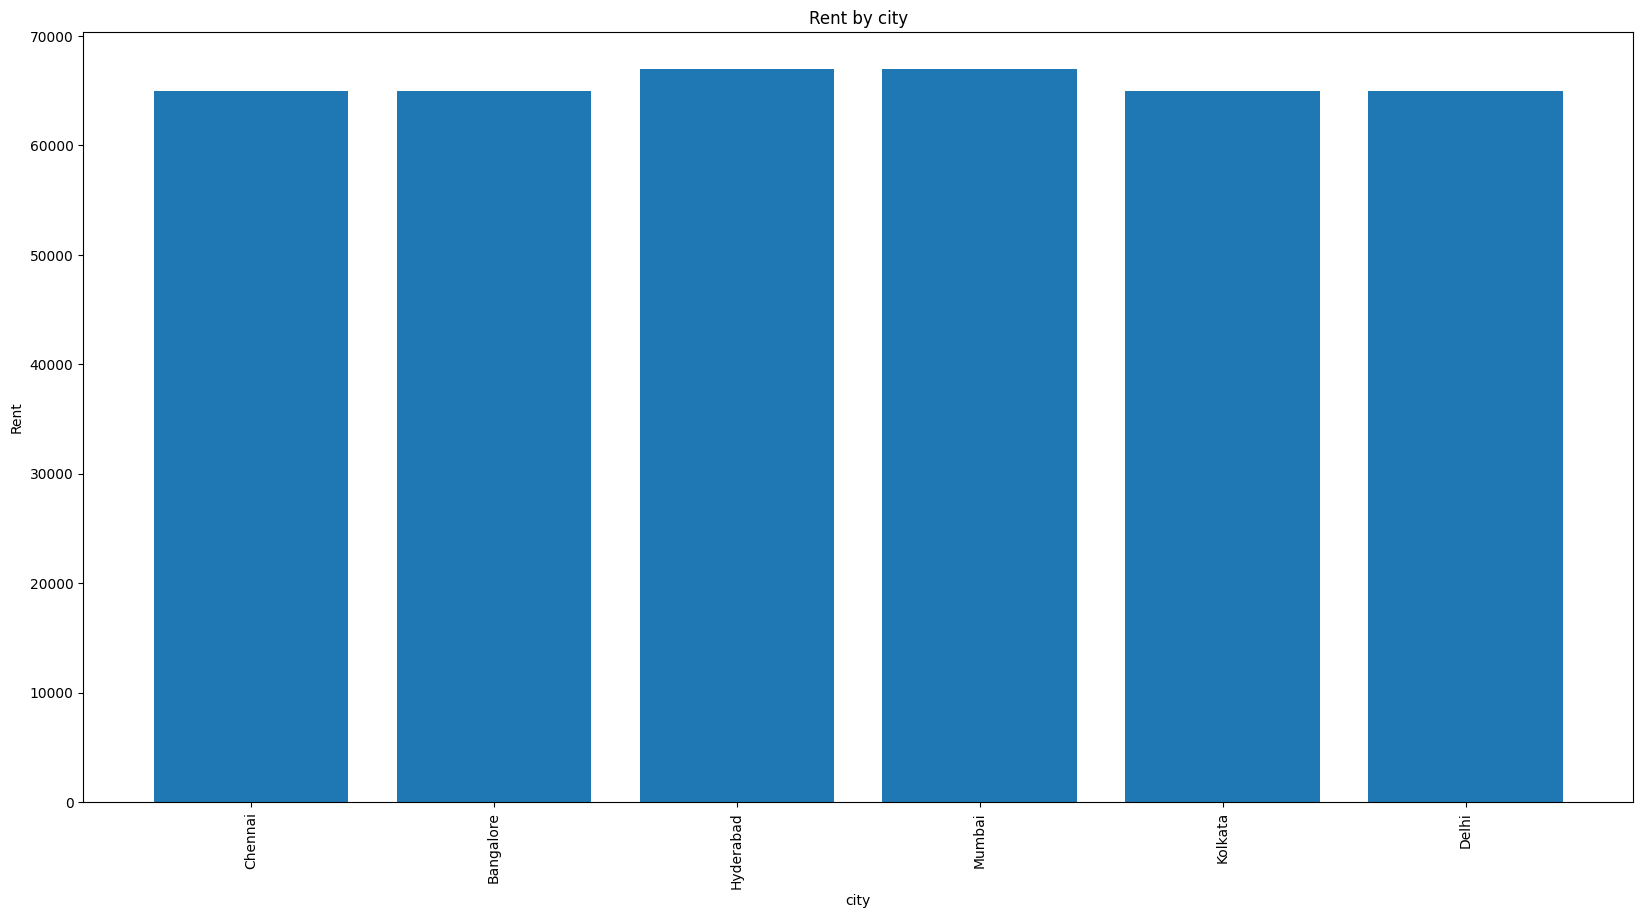

In [61]:
plt.figure(figsize=(20,10))
plt.bar(x_train['City'],y_train)
plt.xlabel('city')
plt.ylabel('Rent')
plt.title('Rent by city')
plt.xticks(rotation=90)
plt.show()

In [62]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3376 entries, 3610 to 1069
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          3376 non-null   object
 1   BHK                3376 non-null   int64 
 2   Size               3376 non-null   object
 3   Floor              3376 non-null   object
 4   Area Type          3376 non-null   object
 5   Area Locality      3376 non-null   object
 6   City               3376 non-null   object
 7   Furnishing Status  3376 non-null   object
 8   Tenant Preferred   3376 non-null   object
 9   Bathroom           3376 non-null   object
 10  Point of Contact   3376 non-null   object
dtypes: int64(1), object(10)
memory usage: 316.5+ KB


In [63]:
x_train['Size']=x_train['Size'].astype('int64')
x_test['Size']=x_test['Size'].astype('int64')
x_train['Bathroom']=x_train['Bathroom'].astype('int64')
x_test['Bathroom']=x_test['Bathroom'].astype('int64')

In [64]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3376 entries, 3610 to 1069
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          3376 non-null   object
 1   BHK                3376 non-null   int64 
 2   Size               3376 non-null   int64 
 3   Floor              3376 non-null   object
 4   Area Type          3376 non-null   object
 5   Area Locality      3376 non-null   object
 6   City               3376 non-null   object
 7   Furnishing Status  3376 non-null   object
 8   Tenant Preferred   3376 non-null   object
 9   Bathroom           3376 non-null   int64 
 10  Point of Contact   3376 non-null   object
dtypes: int64(3), object(8)
memory usage: 316.5+ KB


In [65]:
x_train.drop('Posted On',axis=1,inplace=True)
x_test.drop('Posted On',axis=1,inplace=True)
x_train.drop('Point of Contact',axis=1,inplace=True)
x_test.drop('Point of Contact',axis=1,inplace=True)


In [66]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,binarize 
from sklearn.compose import ColumnTransformer
le = LabelEncoder()

In [67]:
cols = ['Area Type', 'City','Tenant Preferred','Floor','Area Locality']


for col in cols:

    x_train[col] = x_train[col].astype(str)
    x_test[col] = x_test[col].astype(str)


    all_unique_labels = pd.concat([x_train[col], x_test[col]], axis=0).unique()


    le.fit(all_unique_labels)

    x_train[col] = le.transform(x_train[col])
    x_test[col] = le.transform(x_test[col])
    
x_train['Furnishing Status'] = x_train['Furnishing Status'].str.strip()
x_test['Furnishing Status'] = x_test['Furnishing Status'].str.strip()


status_dict = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}


x_train['Furnishing Status'] = x_train['Furnishing Status'].map(status_dict)
x_test['Furnishing Status'] = x_test['Furnishing Status'].map(status_dict)  


In [68]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3376 entries, 3610 to 1069
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   BHK                3376 non-null   int64
 1   Size               3376 non-null   int64
 2   Floor              3376 non-null   int64
 3   Area Type          3376 non-null   int64
 4   Area Locality      3376 non-null   int64
 5   City               3376 non-null   int64
 6   Furnishing Status  3376 non-null   int64
 7   Tenant Preferred   3376 non-null   int64
 8   Bathroom           3376 non-null   int64
dtypes: int64(9)
memory usage: 263.8 KB


In [69]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
y_train=pd.Series(y_train,name="Rent")
y_test=pd.Series(y_test,name="Rent")

<Axes: >

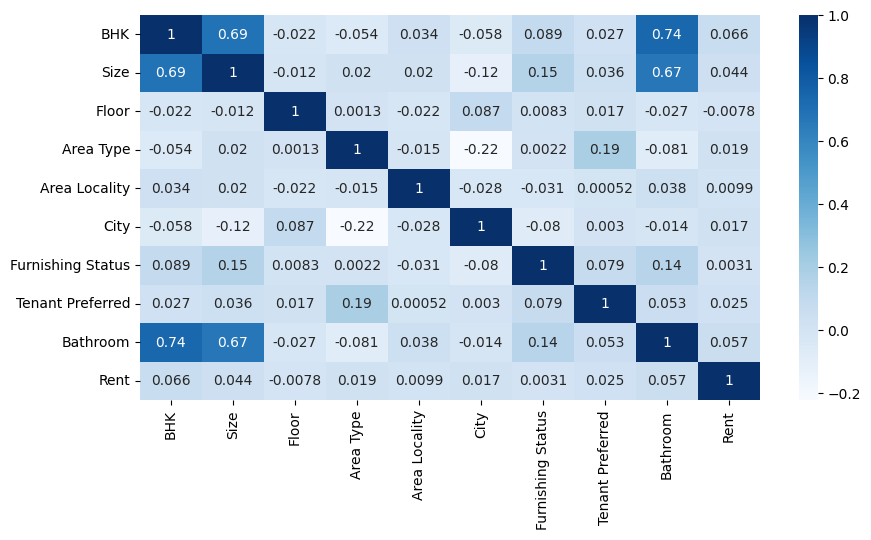

In [70]:
plt.figure(figsize=(10,5))
sns.heatmap(pd.concat([x_train,pd.Series(y_train,name='Rent')],axis=1).corr(),annot=True,cmap='Blues')

In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [72]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [73]:
Model = LinearRegression()
Model.fit(X_train, y_train)
y_pred = Model.predict(X_test)

In [74]:
r2 = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(mean_squared_error(y_test,y_pred))

In [75]:
print(f"R^2 score:{r2:.2%}")
print(f"Mean Absolute Error:{MAE:.2f}")
print(f"Mean Squared Error:{MSE:.2f}")
print(f"Root Mean Squared Error:{RMSE:.2f}")

R^2 score:43.60%
Mean Absolute Error:7861.10
Mean Squared Error:106307217.98
Root Mean Squared Error:10310.54


In [76]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [77]:
dt_model = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=7,
    random_state=100

)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)

In [78]:
r2 = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test,y_pred)
MSE = mean_squared_error(y_test,y_pred)
RMSE = np.sqrt(mean_squared_error(y_test,y_pred))

In [79]:
print(f"R^2 score:{r2:.2%}")
print(f"Mean Absolute Error:{MAE:.2f}")
print(f"Mean Squared Error:{MSE:.2f}")
print(f"Root Mean Squared Error:{RMSE:.2f}")

R^2 score:65.40%
Mean Absolute Error:5527.26
Mean Squared Error:65210127.17
Root Mean Squared Error:8075.28


In [80]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score

In [81]:
model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    objective='reg:squarederror')
    

In [82]:
model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [83]:
y_pred_xgb = model.predict(X_test)

In [84]:
print("XGBoost Regressor Performance:")
r2 = r2_score(y_test, y_pred_xgb)
MAE = mean_absolute_error(y_test,y_pred_xgb)
MSE = mean_squared_error(y_test,y_pred_xgb)
RMSE = np.sqrt(mean_squared_error(y_test,y_pred_xgb))
print(f"R^2 score:{r2:.2%}")
print(f"Mean Absolute Error:{MAE:.2f}")
print(f"Mean Squared Error:{MSE:.2f}")
print(f"Root Mean Squared Error:{RMSE:.2f}")


XGBoost Regressor Performance:
R^2 score:72.41%
Mean Absolute Error:5007.02
Mean Squared Error:52006999.70
Root Mean Squared Error:7211.59
